In [53]:
# --- import libraries ---
import pandas as pd
import numpy as np
import os
import shutil
from lifelines import CoxPHFitter
from lifelines.exceptions import ConvergenceError
from sklearn.preprocessing import StandardScaler
from typing import Tuple, Optional
import matplotlib.pyplot as plt
import seaborn as sns

from stg import STG
import stg.utils as utils
import numpy as np
import torch
import time


PARTICIPANT_DATA_PATH = './participant_data/'

## Prepare dataset

In [54]:
# datasets = utils.load_cox_gaussian_data()

'datasets' should have a following structure:

```{python}
    datasets = {'train': {'x': (n_train, d) observations (dtype = float32),
                          't': (n_train) event times (dtype = float32),
                          'e': (n_train) event indicators (dtype = int32)},
                'test': {'x': (n_test, d) observations (dtype = float32),
                          't': (n_test) event times (dtype = float32),
                          'e': (n_test) event indicators (dtype = int32)},
                'valid': {'x': (n_valid, d) observations (dtype = float32),
                          't': (n_valid) event times (dtype = float32),
                          'e': (n_valid) event indicators (dtype = int32)}}
```

In [55]:
from utilities.preprocess import preprocess

index_event = "Borrow"
outcome_event = "Liquidated"
dataset_path = os.path.join(index_event, outcome_event)

train_df = pd.read_csv(os.path.join(PARTICIPANT_DATA_PATH, dataset_path, 'train.csv'))
test_features_df = pd.read_csv(os.path.join(PARTICIPANT_DATA_PATH, dataset_path, 'test_features.csv'))
X_train, y_train, X_test_processed = preprocess(train_df, test_features_df)
lifelines_train_df = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)

In [56]:
# lifelines_train_df.info()

In [57]:
# separate features (X), times (t), and events (e)
X = lifelines_train_df.drop(columns=["timeDiff", "status"]).values.astype(np.float32)
t = lifelines_train_df["timeDiff"].values.astype(np.float32)
e = lifelines_train_df["status"].values.astype(np.int32)

In [58]:
from sklearn.model_selection import train_test_split

train_valid_df, test_df = train_test_split(lifelines_train_df, test_size=0.2, random_state=42)
train_df, valid_df = train_test_split(train_valid_df, test_size=0.2, random_state=42)

# helper function to extract X, t, e
def extract_X_t_e(df):
    X = df.drop(columns=["timeDiff", "status"]).values.astype(np.float32)
    t = df["timeDiff"].values.astype(np.float32)
    e = df["status"].values.astype(np.int32)
    return X, t, e

# extract for each split
X_train, t_train, e_train = extract_X_t_e(train_df)
X_valid, t_valid, e_valid = extract_X_t_e(valid_df)
X_test, t_test, e_test = extract_X_t_e(test_df)

# build dictionary
datasets = {
    'train': {'X': X_train, 'T': t_train, 'E': e_train},
    'valid': {'X': X_valid, 'T': t_valid, 'E': e_valid},
    'test':  {'X': X_test,  'T': t_test,  'E': e_test}
}

# Check
for split in datasets:
    print(f"{split} X: {datasets[split]['X'].shape}, T: {datasets[split]['T'].shape}, E: {datasets[split]['E'].shape}")


train X: (566980, 78), T: (566980,), E: (566980,)
valid X: (141746, 78), T: (141746,), E: (141746,)
test X: (177182, 78), T: (177182,), E: (177182,)


## Instantiate the STG trainer

In [59]:
for split in datasets:
    print(f"{split} X: {datasets[split]['X'].shape}, T: {datasets[split]['T'].shape}, E: {datasets[split]['E'].shape}")

train X: (566980, 78), T: (566980,), E: (566980,)
valid X: (141746, 78), T: (141746,), E: (141746,)
test X: (177182, 78), T: (177182,), E: (177182,)


In [60]:
import collections
import collections.abc

collections.Sequence = collections.abc.Sequence
collections.Set = collections.abc.Set
collections.Mapping = collections.abc.Mapping


device = "cpu"
feature_selection = True

# Get training data from datasets dictionary
train_data = datasets['train']
valid_data = datasets['train']

# Initialize STG model
model = STG(
    task_type='cox',
    input_dim=X_train.shape[1],      # number of features
    output_dim=1,
    hidden_dims=[60, 20, 3],
    activation='selu',
    optimizer='Adam',
    learning_rate=0.0005,
    batch_size=X_train.shape[0],      # full batch
    feature_selection=feature_selection,
    sigma=0.5,
    lam=0.004,
    random_state=1,
    device=device,
)

## Training

In [61]:
now = time.time()

model.fit(train_data['X'], 
          {'E': train_data['E'], 
           'T': train_data['T']}, 
           nr_epochs=100,
           valid_X=valid_data['X'], 
           valid_y={'E': valid_data['E'], 
           'T': valid_data['T']}, 
           print_interval=100,)

print("Passed Time: {}".format(time.time() - now))

Epoch: 100: CI=0.772809 loss=75.541626 valid_CI=0.797598 valid_loss=11.813197
Passed Time: 415.4263503551483


## Evaluating the model

In [62]:
test_data = datasets['test']

model.evaluate(test_data['X'], {'E': test_data['E'], 'T': test_data['T']})

 test_CI=0.803472 test_loss=10.634555


In [63]:
model.get_gates(mode='prob')
importance = (model.get_gates(mode='prob'))
print(importance)

[0.44241607 0.4531594  0.4574303  0.44557568 0.45606473 0.46416408
 0.4657747  0.44565886 0.44473195 0.44876784 0.43960106 0.4579687
 0.45095408 0.45151085 0.44463924 0.45765185 0.45781997 0.44408503
 0.43959236 0.43610305 0.45534745 0.45202684 0.44936314 0.45947385
 0.43918788 0.43651417 0.44391295 0.46907392 0.4426854  0.4559381
 0.43785188 0.457287   0.4369901  0.44299883 0.46030915 0.45691893
 0.4573049  0.4524766  0.45968303 0.46276578 0.4559128  0.45269436
 0.45314378 0.45685723 0.45565164 0.44343558 0.4338368  0.46447214
 0.44778952 0.4610628  0.46056926 0.42469108 0.4487972  0.46552154
 0.4500253  0.44254616 0.43303424 0.43642548 0.4456026  0.45731345
 0.4504042  0.45985308 0.47728845 0.46199852 0.45786846 0.43614432
 0.4440185  0.43591368 0.4655279  0.439191   0.45540547 0.44365287
 0.4541709  0.45344445 0.43874168 0.44103166 0.45741457 0.4512403 ]


In [84]:
new_df = train_df.copy()
new_df = new_df.drop(["status", "timeDiff"], axis=1)
features = (new_df.columns).tolist()
len(features), len(train_df.keys())

(78, 80)

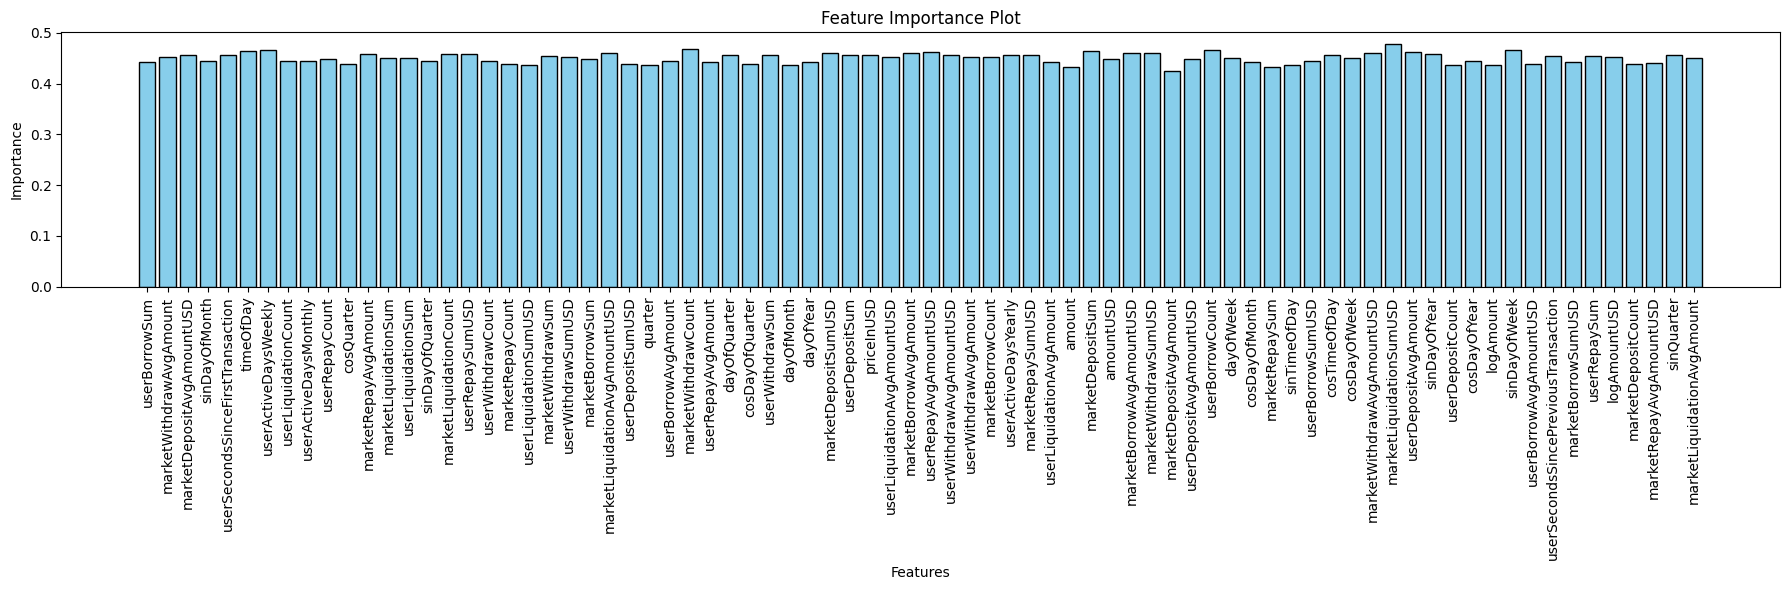

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

plt.bar(features, importance, width=0.8, color='skyblue', edgecolor='black')

plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=90)  # rotate labels to prevent overlap
plt.title("Feature Importance Plot")
plt.tight_layout()  # adjusts layout to prevent clipping of labels
plt.show()

## Saving and loading

In [64]:
# model.save_checkpoint('trained_model.pt')

In [65]:
# model_tmp = STG(task_type='cox',input_dim=train_data['X'].shape[1], output_dim=1, hidden_dims=[60, 20, 3], activation='selu',
#     optimizer='Adam', learning_rate=0.0005, batch_size=train_data['X'].shape[0], feature_selection=feature_selection,
#     sigma=0.5, lam=0.004, random_state=1, device=device)

In [66]:
# model_tmp.load_checkpoint('trained_model.pt')

## Checking the performance of the loaded model

In [67]:
# model_tmp.evaluate(test_data['X'], {'E': test_data['E'], 'T': test_data['T']})